In [1]:
from sklearn.datasets import fetch_california_housing 
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as ctx
from matplotlib.colors import Normalize
import matplotlib.cm as cm



In [2]:
imoveis = fetch_california_housing(as_frame=True)
dados = imoveis.frame

dados.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


# Dicionário e descrição das variáveis

| Variável       | Tipo       | Descrição                                                                 |
|----------------|-----------|---------------------------------------------------------------------------|
| MedInc         | Numérica  | Renda mediana dos domicílios no grupo de blocos                           |
| HouseAge       | Numérica  | Idade mediana das casas no grupo de blocos                                |
| AveRooms       | Numérica  | Número médio de cômodos por domicílio                                     |
| AveBedrms      | Numérica  | Número médio de quartos de dormir por domicílio                           |
| Population     | Numérica  | População total do grupo de blocos                                         |
| AveOccup       | Numérica  | Número médio de ocupantes por domicílio                                   |
| Latitude       | Numérica  | Latitude do centro do grupo de blocos                                     |
| Longitude      | Numérica  | Longitude do centro do grupo de blocos                                    |
| MedHouseVal    | Numérica  | Valor mediano das casas no grupo de blocos (target da regressão)          |


O California Housing Dataset é um conjunto de dados derivado do Censo americano de 1990, onde cada registro representa um grupo de quarteirões censitários da Califórnia, a menor unidade geográfica para a qual o US Census Bureau publica dados amostrais. Cada grupo de quarteirões geralmente possui entre 600 e 3.000 pessoas. A variável alvo é o valor médio das casas nesses grupos, expresso em centenas de milhares de dólares (US$ 100.000). O dataset inclui informações demográficas e geográficas, como renda mediana dos domicílios, idade média das casas, número médio de quartos e cômodos por domicílio, população e ocupação média. Como os valores médios de cômodos e quartos são calculados por domicílio, algumas colunas podem apresentar valores altos em grupos de quarteirões com poucos domicílios e muitas casas vazias, como resorts de férias. Este conjunto de dados é amplamente utilizado para tarefas de regressão linear cross-section, permitindo analisar como características socioeconômicas e geográficas influenciam o valor das propriedades.

# EDA

In [3]:
dados.shape

(20640, 9)

In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
dados.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


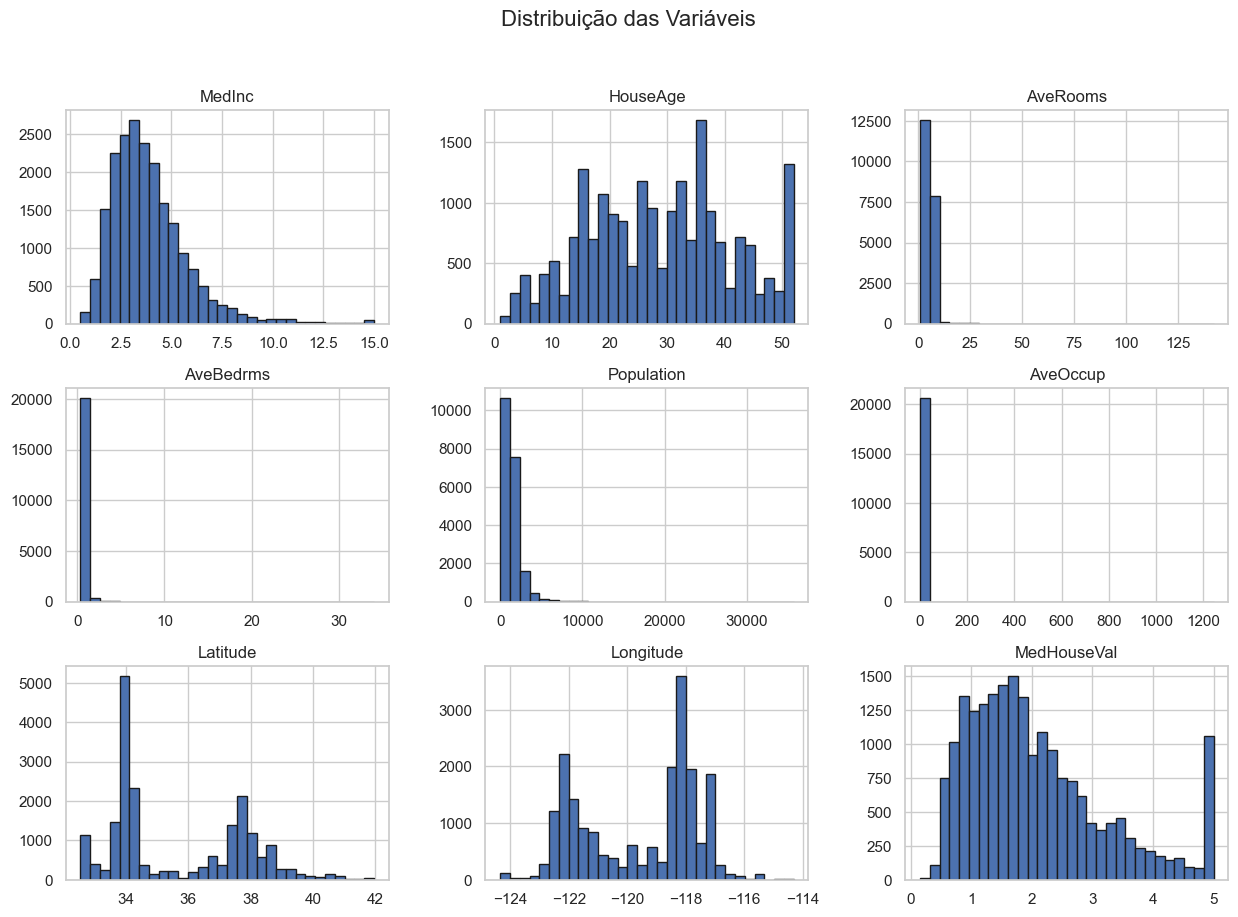

In [6]:
# Configuração de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


# Histogramas
dados.hist(bins=30, figsize=(15,10), edgecolor='k')
plt.suptitle("Distribuição das Variáveis", fontsize=16)
plt.show()

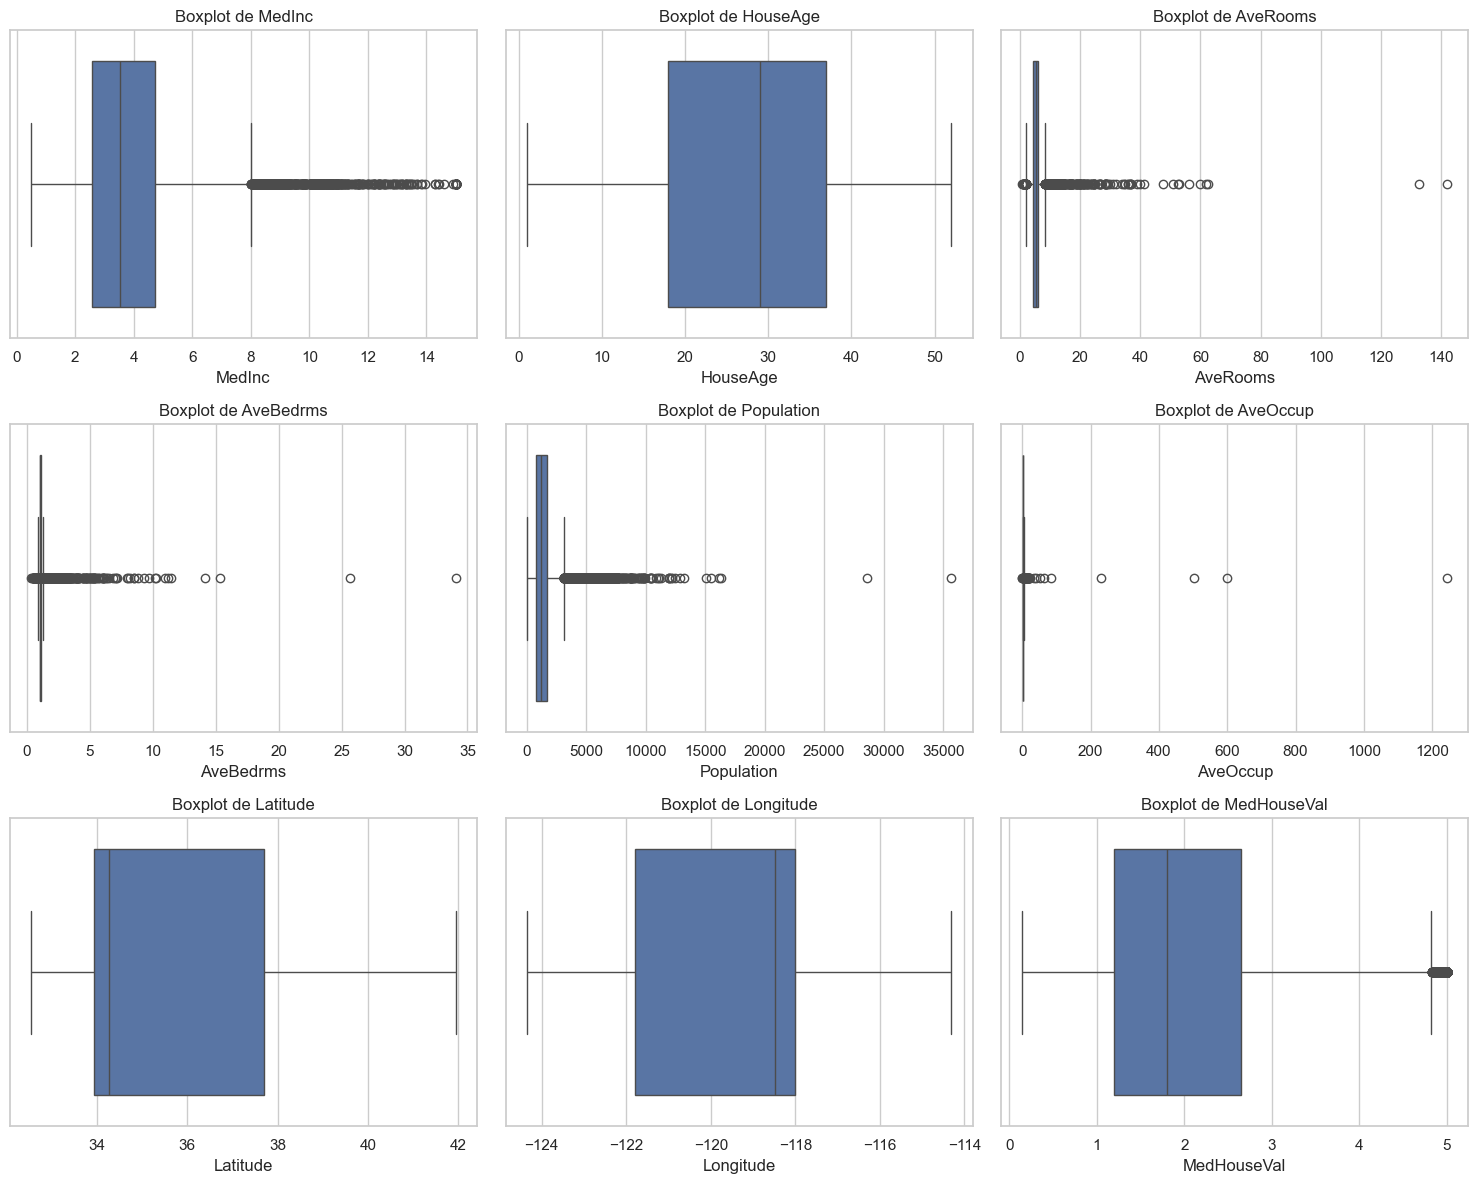

In [ ]:
# Número de variáveis
cols = dados.columns
n = len(cols)

# tamanho da figura e layout 
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols  # calcula linhas necessárias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))

# Flatten axes para iterar 
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=dados[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")

# Remove subplots vazios, se houver
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

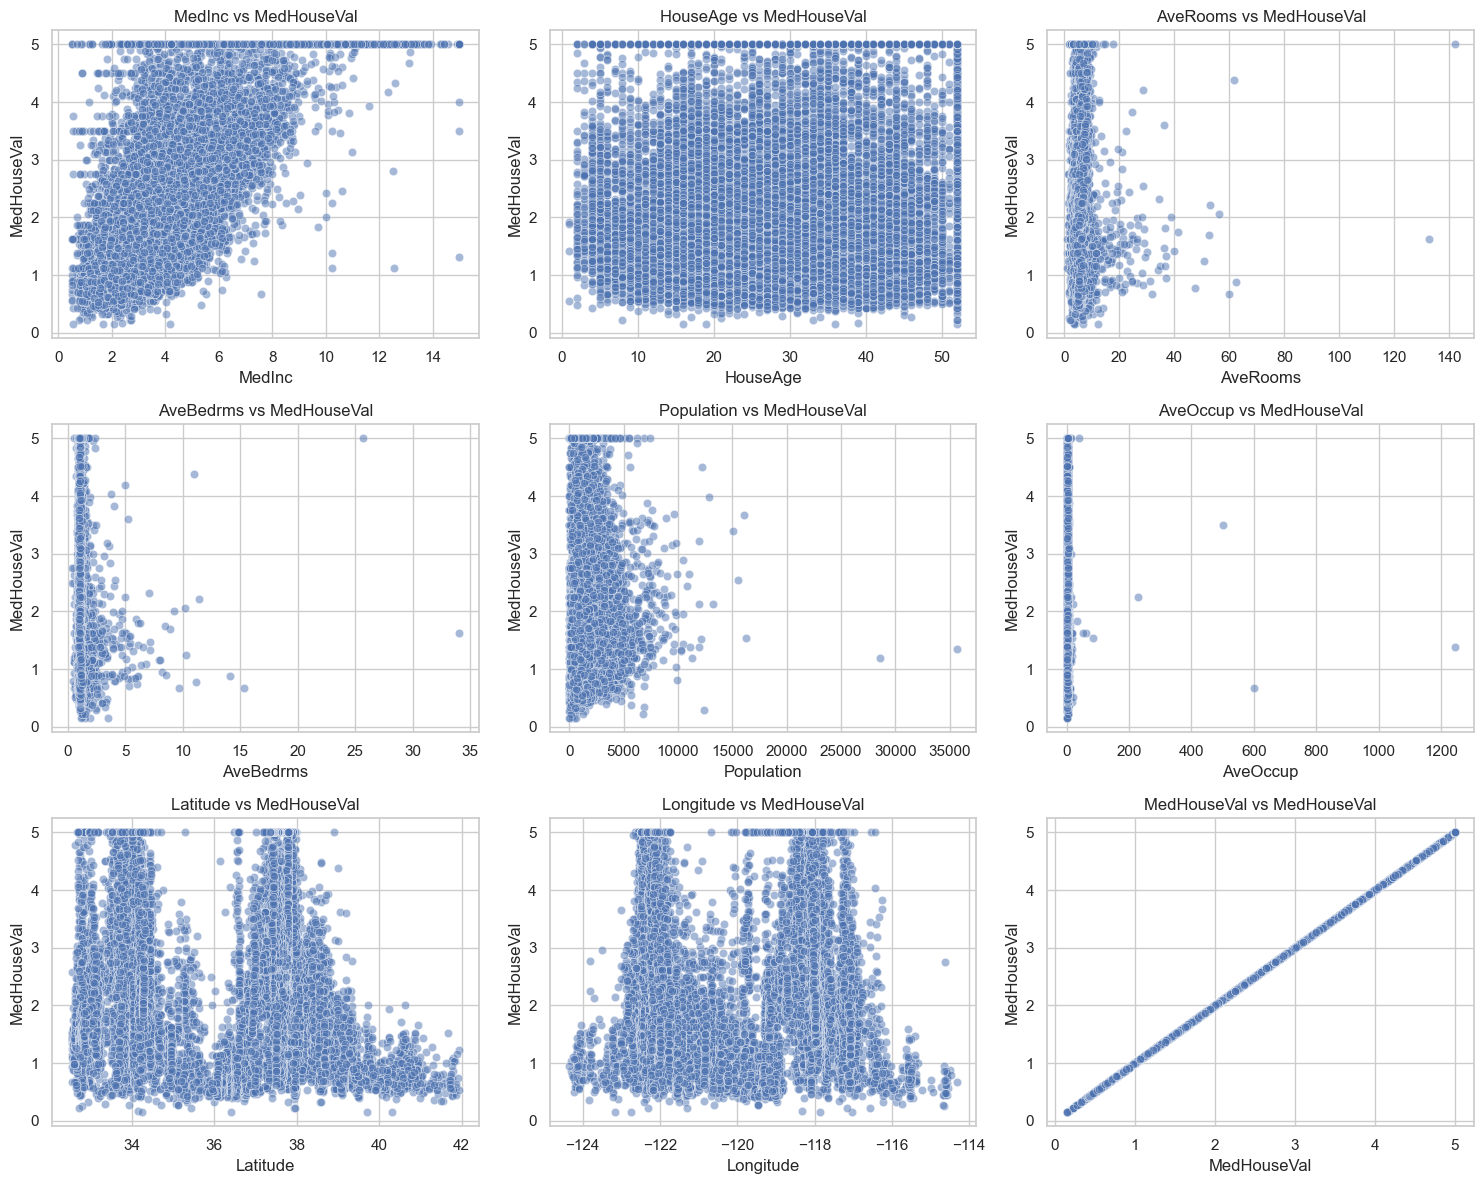

In [ ]:
features = dados.columns #nome das colunas para o plot   
n = len(features)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=dados[col], y=dados['MedHouseVal'], ax=axes[i], alpha=0.5)
    axes[i].set_title(f"{col} vs MedHouseVal")

# Remover subplots vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


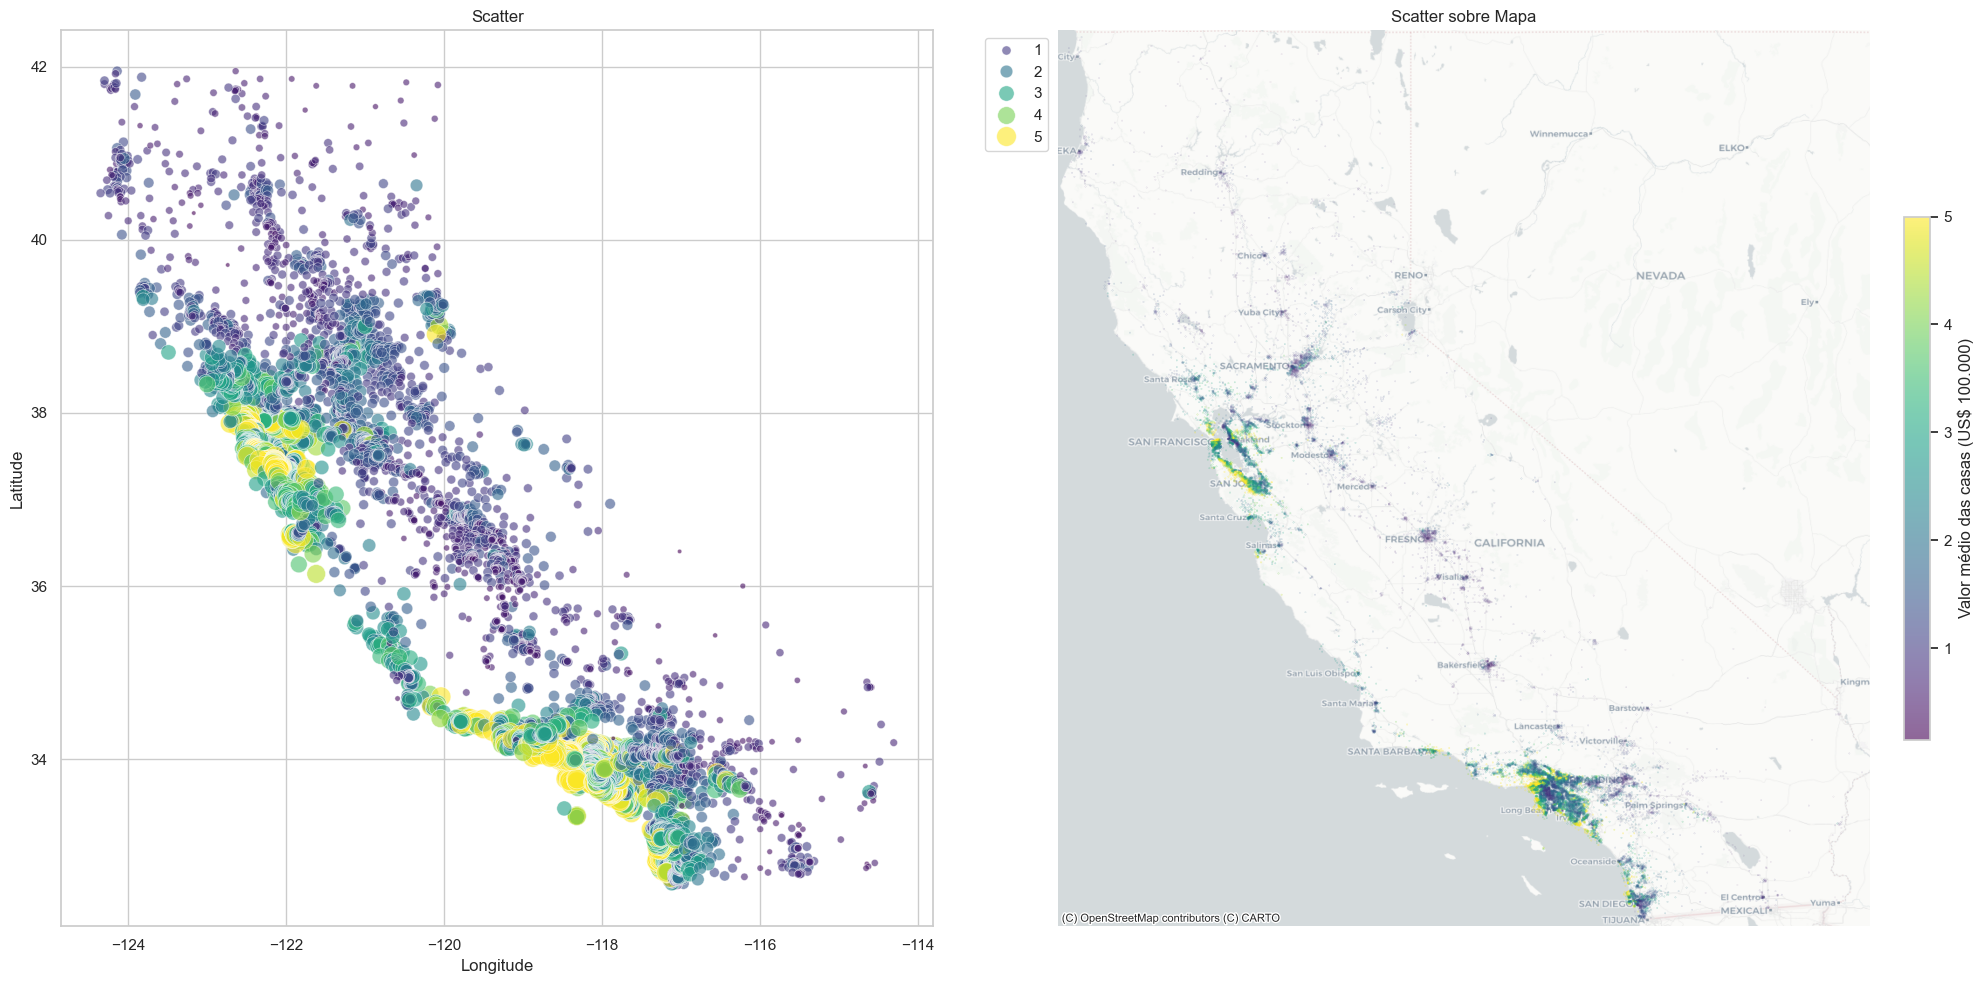

In [11]:
# GeoDataFrame
gdf = gpd.GeoDataFrame(
    dados,
    geometry=gpd.points_from_xy(dados['Longitude'], dados['Latitude']),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(epsg=3857)

#config 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20,10))


# Scatter plot 
sns.scatterplot(
    x='Longitude', y='Latitude',
    hue='MedHouseVal', size='MedHouseVal',
    palette='viridis', sizes=(10,200), alpha=0.6,
    data=dados,
    ax=axes[0]
)
axes[0].set_title("Scatter")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc=2)


# Scatter plot sobre mapa (GeoPandas + Contextily)

norm = Normalize(vmin=gdf['MedHouseVal'].min(), vmax=gdf['MedHouseVal'].max())
cmap = cm.viridis

sc = axes[1].scatter(
    gdf.geometry.x, gdf.geometry.y,
    s=gdf['MedHouseVal']/100,
    c=gdf['MedHouseVal'],
    cmap=cmap,
    alpha=0.6
)

# mapa base
ctx.add_basemap(axes[1], source=ctx.providers.CartoDB.Positron)

# Ajusta limites para zoom
axes[1].set_xlim(gdf.geometry.x.min() - 1e4, gdf.geometry.x.max() + 1e4)
axes[1].set_ylim(gdf.geometry.y.min() - 1e4, gdf.geometry.y.max() + 1e4)

# Legenda 
cbar = plt.colorbar(sc, ax=axes[1], fraction=0.03, pad=0.04)
cbar.set_label("Valor médio das casas (US$ 100.000)")

axes[1].set_axis_off()
axes[1].set_title("Scatter sobre Mapa")

plt.tight_layout()
plt.show()


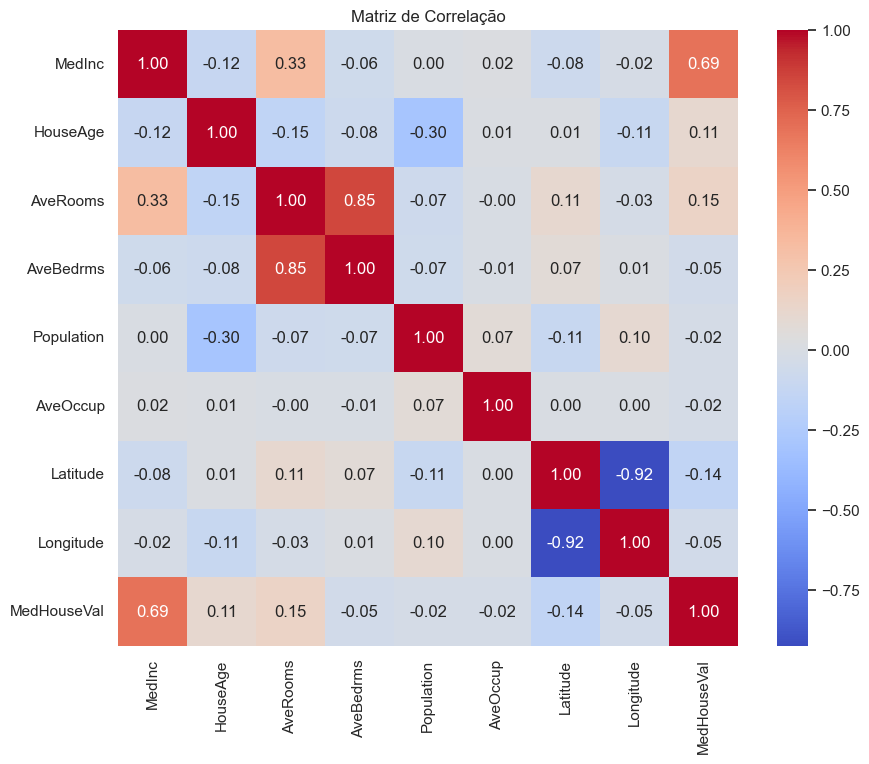

In [10]:
corr = dados.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()
